### Light GBM

In [7]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

df = pd.read_parquet('final_32_columns_no_outliers.parquet')

In [2]:
X = df.drop('totalFare', axis=1)
y = df['totalFare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (643928, 32)
X_test shape: (160982, 32)
y_train shape: (643928,)
y_test shape: (160982,)


### Speeding up RandomizedSearchCV with a Data Subset



In [3]:
sample_fraction = 0.1
X_train_subset, _, y_train_subset, _ = train_test_split(X_train, y_train, test_size=1 - sample_fraction, random_state=42)

print(f"X_train_subset shape: {X_train_subset.shape}")
print(f"y_train_subset shape: {y_train_subset.shape}")

X_train_subset shape: (64392, 32)
y_train_subset shape: (64392,)


In [4]:
# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'num_leaves': randint(20, 40),
    'max_depth': randint(5, 15),
    'learning_rate': uniform(0.01, 0.1),
    'n_estimators': randint(100, 500),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0, 0.5)
}

# Initialize the LightGBM Regressor model
lgbm_base = lgb.LGBMRegressor(objective='regression', random_state=42, n_jobs=-1)

# Initialize RandomizedSearchCV again, using the data subset
random_search_subset = RandomizedSearchCV(estimator=lgbm_base, param_distributions=param_dist,
                                        n_iter=5, scoring='neg_mean_squared_error', cv=2,
                                        verbose=2, random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV to the training data subset
random_search_subset.fit(X_train_subset, y_train_subset)

print("Randomized Search on subset complete.")
print(f"Best parameters found on subset: {random_search_subset.best_params_}")
print(f"Best RMSE found on subset: {np.sqrt(-random_search_subset.best_score_):.2f}")

Fitting 2 folds for each of 5 candidates, totalling 10 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018936 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3211
[LightGBM] [Info] Number of data points in the train set: 64392, number of used features: 31
[LightGBM] [Info] Start training from score 341.898531
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [5]:
print("Optimal Hyperparameters from RandomizedSearchCV:")
for param, value in random_search_subset.best_params_.items():
    print(f"  {param}: {value}")

Optimal Hyperparameters from RandomizedSearchCV:
  colsample_bytree: 0.6186662652854461
  learning_rate: 0.10737555188414592
  max_depth: 7
  n_estimators: 463
  num_leaves: 39
  reg_alpha: 0.29620728443102123
  reg_lambda: 0.023225206359998862
  subsample: 0.8430179407605753


### Train Final Model with Best Parameters on Full Dataset

In [8]:
# Get the best parameters from the RandomizedSearchCV on the subset
best_params = random_search_subset.best_params_

# Initialize the final LightGBM model with the best parameters
final_lgbm_model = lgb.LGBMRegressor(objective='regression', random_state=42, n_jobs=-1, **best_params)

# Train the final model on the full training data
final_lgbm_model.fit(X_train, y_train)

print("Final LightGBM model trained successfully on full dataset.")

# Make predictions on the test set using the final model
y_pred_final = final_lgbm_model.predict(X_test)

# Evaluate the final model
mse_final = mean_squared_error(y_test, y_pred_final)
rmse_final = np.sqrt(mse_final)
r_squared_final = r2_score(y_test, y_pred_final)

print(f"Final Model - Mean Squared Error (MSE): {mse_final:.2f}")
print(f"Final Model - Root Mean Squared Error (RMSE): {rmse_final:.2f}")
print(f"Final Model - R-squared: {r_squared_final:.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.193994 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3208
[LightGBM] [Info] Number of data points in the train set: 643928, number of used features: 31
[LightGBM] [Info] Start training from score 341.677347
Final LightGBM model trained successfully on full dataset.
Final Model - Mean Squared Error (MSE): 8477.08
Final Model - Root Mean Squared Error (RMSE): 92.07
Final Model - R-squared: 0.72


In [9]:
mae_final = mean_absolute_error(y_test, y_pred_final)

mape_final = mean_absolute_percentage_error(y_test, y_pred_final) * 100

absolute_errors = np.abs(y_test - y_pred_final)

within_25_count = np.sum(absolute_errors <= 25)

within_25_percentage = (within_25_count / len(y_test)) * 100

print("--- LaTeX Table Metrics ---")
print(f"Testing MAE: ${mae_final:.2f}")
print(f"Testing MAPE: {mape_final:.2f}%")
print(f"P(|Prediction error|) < $25: {within_25_percentage:.2f}%")

--- LaTeX Table Metrics ---
Testing MAE: $67.49
Testing MAPE: 23.72%
P(|Prediction error|) < $25: 26.84%


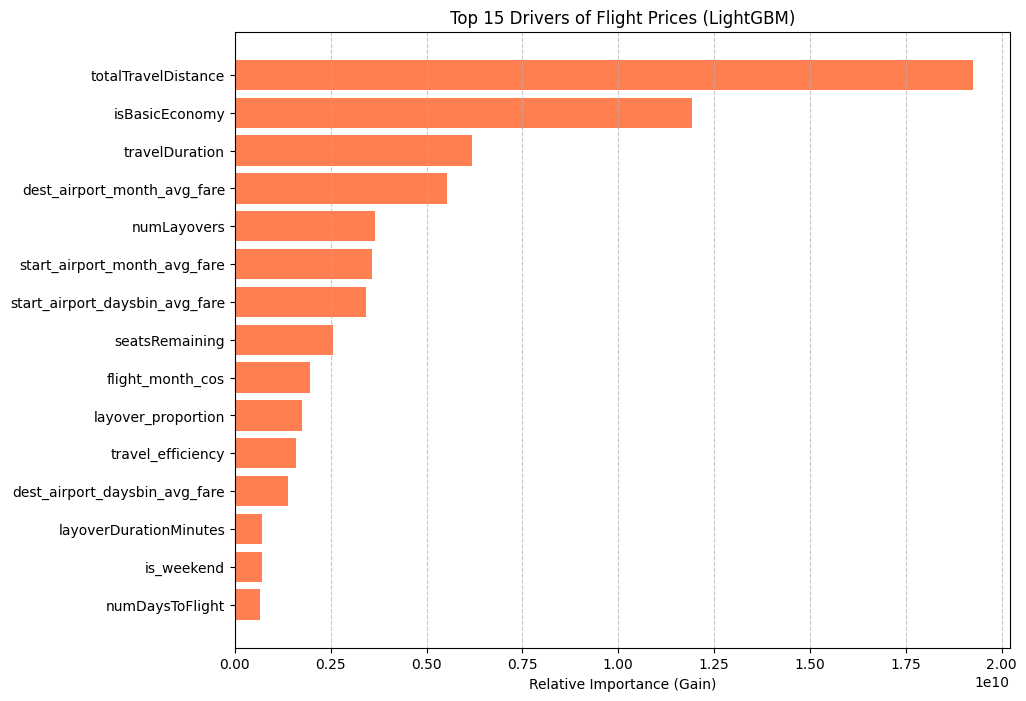

In [10]:
importances = final_lgbm_model.booster_.feature_importance(importance_type='gain')
feature_names = X_test.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='#ff7f50') # Coral color
plt.xlabel('Relative Importance (Gain)')
plt.title('Top 15 Drivers of Flight Prices (LightGBM)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()